In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

In [3]:
# Load feature matrix
X_combined = np.load("X_combined.npy")

# Load regression target
y_pIC50 = np.load("y_pIC50.npy")

print(X_combined.shape)
print(y_pIC50.shape)

(979, 1032)
(979,)


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y_pIC50,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)


Epoch  10/60 | Loss: 0.7099
Epoch  20/60 | Loss: 0.6210
Epoch  30/60 | Loss: 0.4700
Epoch  40/60 | Loss: 0.5303
Epoch  50/60 | Loss: 0.4335
Epoch  60/60 | Loss: 0.4338


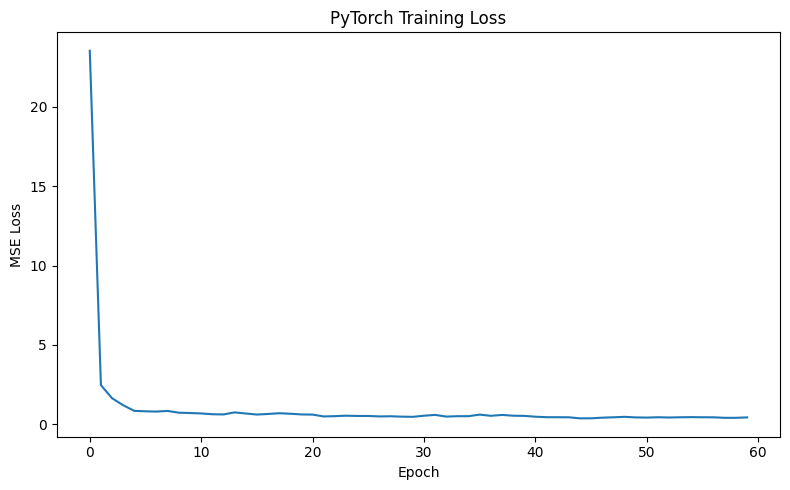


PyTorch NN → R²: 0.525 | RMSE: 1.030
PyTorch metrics saved


In [6]:
# ─── Prepare tensors ──────────────────────────────────────────────────────────
X_tr_t = torch.FloatTensor(X_train_sc)
y_tr_t = torch.FloatTensor(y_train).view(-1, 1)
X_te_t = torch.FloatTensor(X_test_sc)
y_te_t = torch.FloatTensor(y_test).view(-1, 1)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# ─── Define Network Architecture ──────────────────────────────────────────────
class ADMETNet(nn.Module):
    """
    Feedforward neural network for pIC50 regression.
    Architecture: Input → 512 → 256 → 128 → 1
    """
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)   # Single output: pIC50
        )

    def forward(self, x):
        return self.network(x)

# ─── Training Loop ────────────────────────────────────────────────────────────
input_dim = X_train_sc.shape[1]
model     = ADMETNet(input_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 60
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f}")

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(train_losses)

ax.set_title("PyTorch Training Loss")

ax.set_xlabel("Epoch")

ax.set_ylabel("MSE Loss")

plt.tight_layout()

plt.show()

# ─── Evaluation ───────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_nn = model(X_te_t).numpy().flatten()

r2_nn   = r2_score(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
print(f"\nPyTorch NN → R²: {r2_nn:.3f} | RMSE: {rmse_nn:.3f}")

nn_metrics = {
    "r2_nn": r2_nn,
    "rmse_nn": rmse_nn
}

np.save("nn_metrics.npy", nn_metrics)

print("PyTorch metrics saved")

In [7]:
import os
import pandas as pd


# Create results folder
os.makedirs("results", exist_ok=True)


# LOAD SAVED METRICS
classical_metrics = np.load(
    "classical_model_metrics.npy",
    allow_pickle=True
).item()

rf_metrics = np.load(
    "rf_metrics.npy",
    allow_pickle=True
).item()

nn_metrics = np.load(
    "nn_metrics.npy",
    allow_pickle=True
).item()


# Extract variables
r2_ridge = classical_metrics["r2_ridge"]
r2_lasso = classical_metrics["r2_lasso"]
r2_en = classical_metrics["r2_en"]
r2_svr = classical_metrics["r2_svr"]

rmse_ridge = classical_metrics["rmse_ridge"]

acc_svm = classical_metrics["acc_svm"]
auc_svm = classical_metrics["auc_svm"]

r2_rf_reg = rf_metrics["r2_rf_reg"]

acc_rf = rf_metrics["acc_rf"]
auc_rf = rf_metrics["auc_rf"]

r2_nn = nn_metrics["r2_nn"]
rmse_nn = nn_metrics["rmse_nn"]

# Regression Model Comparison

results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Lasso',
        'ElasticNet',
        'SVR',
        'RF Regressor',
        'PyTorch NN'
    ],

    'Task': ['Regression'] * 6,

    'R²': [
        r2_ridge,
        r2_lasso,
        r2_en,
        r2_svr,
        r2_rf_reg,
        r2_nn
    ],

    'RMSE': [
        rmse_ridge,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        rmse_nn
    ]
})

results = results.sort_values('R²', ascending=False)


# Classification Model Comparison
clf_results = pd.DataFrame({
    'Model': [
        'SVM Classifier',
        'RF Classifier'
    ],

    'Task': ['Classification'] * 2,

    'Accuracy': [
        acc_svm,
        acc_rf
    ],

    'AUC-ROC': [
        auc_svm,
        auc_rf
    ]
})



# Save Results
results.to_csv("results/model_comparison.csv", index=False)

clf_results.to_csv(
    "results/classification_model_comparison.csv",
    index=False
)


# Display Results
print("\nRegression Models:")
print(results.to_string(index=False))

print("\nClassification Models:")
print(clf_results.to_string(index=False))


Regression Models:
           Model       Task       R²     RMSE
             SVR Regression 0.691453      NaN
           Lasso Regression 0.678214      NaN
      ElasticNet Regression 0.647420      NaN
    RF Regressor Regression 0.629711      NaN
      PyTorch NN Regression 0.525061 1.029575
Ridge Regression Regression 0.416858 1.140844

Classification Models:
         Model           Task  Accuracy  AUC-ROC
SVM Classifier Classification  0.908163 0.954849
 RF Classifier Classification  0.918367 0.964245
